# Evaluating & Monitoring an LLM-Powered Feature: Technical Walkthrough

A generic company ships an LLM-drafted reply feature for its support inbox: the model drafts a response, and (depending on risk) it's either auto-sent or routed to a human reviewer. This notebook covers the data-science layer around that feature, not the feature itself: validating the automated judge used to score reply quality, A/B testing a prompt change, monitoring quality in production, and picking a cost-based auto-send threshold.

For the short, stakeholder-facing version of this project see the [project README](../README.md).

All data here is synthetic, generated by `src/generate_data.py`. This project is intentionally domain-agnostic (not tied to the fictional BNPL company in projects 01-03) since the eval/monitoring methodology here is meant to generalize across any LLM-powered feature, not read as a one-company feature demo.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from style import set_style, style_ax, savefig, add_footnote, SLATE, MUTED_TEAL, MUTED_AMBER, MUTED_RED, GREY, PALETTE

set_style()
pd.set_option("display.max_columns", 50)
%matplotlib inline

## 1. Validating the LLM-judge against human labels

Using an LLM to grade LLM output (an "LLM-judge") is common because human review of every reply doesn't scale. But the judge itself needs validating before anything downstream trusts it: a 600-ticket golden set was scored by both a human rater and the judge, on a 1-5 Likert scale. Raw percent agreement overstates reliability on a scale like this, since two independent raters land on the same score some of the time by chance alone; Cohen's kappa corrects for that by measuring agreement beyond chance, and the quadratic-weighted variant used below also penalizes a 1-vs-5 mismatch far more than a 3-vs-4 one, matching how much those two kinds of disagreement actually matter.

In [2]:
from sklearn.metrics import cohen_kappa_score
from scipy import stats

golden = pd.read_csv("../data/golden_eval_set.csv")
SOURCE_GOLDEN = f"Source: synthetic golden eval set · n = {len(golden):,} labeled tickets"

human = golden["human_label"].values
judge = golden["judge_label"].values
diff = judge - human

exact_agreement = float(np.mean(human == judge))
adjacent_agreement = float(np.mean(np.abs(diff) <= 1))
kappa = float(cohen_kappa_score(human, judge, weights="quadratic"))
bias_overall = float(diff.mean())
t_stat, bias_p = stats.ttest_1samp(diff, 0)

print(f"Exact agreement: {exact_agreement:.1%}   Within-1 agreement: {adjacent_agreement:.1%}")
print(f"Quadratic-weighted kappa: {kappa:.3f}")
print(f"Judge bias: {bias_overall:+.2f} points (p={bias_p:.5f})")

Exact agreement: 52.7%   Within-1 agreement: 96.7%
Quadratic-weighted kappa: 0.491
Judge bias: +0.31 points (p=0.00000)


A kappa below about 0.60 falls short of the commonly-cited "substantial agreement" floor. Combined with a judge that's systematically more generous than the human rater by roughly a third of a Likert point, the takeaway isn't "the judge is broken," it's "the judge's absolute scores can't be taken at face value without periodic human-labeled audits." Whether that's good enough depends entirely on what the judge is used for downstream; a relative A/B comparison (section 2) tolerates a consistent bias far better than an absolute quality gate does.

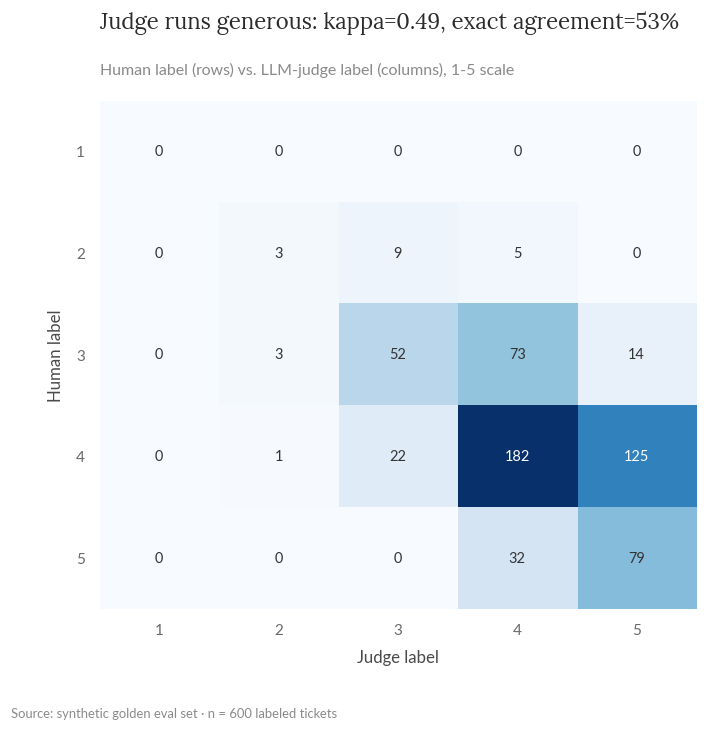

In [3]:
labels = [1, 2, 3, 4, 5]
mat = pd.crosstab(golden["human_label"], golden["judge_label"]).reindex(index=labels, columns=labels, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(mat.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(5)); ax.set_xticklabels(labels)
ax.set_yticks(range(5)); ax.set_yticklabels(labels)
for i in range(5):
    for j in range(5):
        v = mat.values[i, j]
        ax.text(j, i, str(v), ha="center", va="center", fontsize=9.5,
                color="white" if v > mat.values.max() * 0.5 else "#333")
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
style_ax(ax, title=f"Judge runs generous: kappa={kappa:.2f}, exact agreement={exact_agreement:.0%}",
         subtitle="Human label (rows) vs. LLM-judge label (columns), 1-5 scale",
         xlabel="Judge label", ylabel="Human label", grid_axis=None)
add_footnote(fig, SOURCE_GOLDEN)
plt.show()

**Figure 1.** Judge score vs. human score, confusion matrix over the golden set.

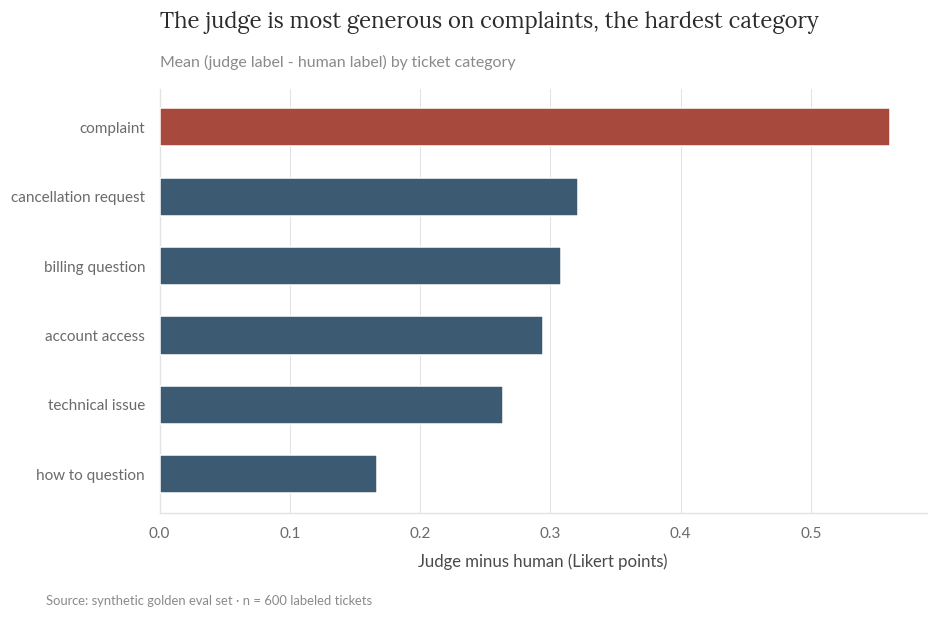

category
complaint               0.56
cancellation_request    0.32
billing_question        0.31
account_access          0.29
technical_issue         0.26
how_to_question         0.17
Name: diff, dtype: float64

In [4]:
bias_by_category = golden.assign(diff=diff).groupby("category")["diff"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [MUTED_RED if v == bias_by_category.max() else SLATE for v in bias_by_category.values]
ax.barh([c.replace("_", " ") for c in bias_by_category.index], bias_by_category.values, color=colors, zorder=3, height=0.55)
ax.axvline(0, color=GREY, linewidth=1)
ax.invert_yaxis()
style_ax(ax, title="The judge is most generous on complaints, the hardest category",
         subtitle="Mean (judge label - human label) by ticket category",
         xlabel="Judge minus human (Likert points)", grid_axis="x")
add_footnote(fig, SOURCE_GOLDEN)
plt.show()
bias_by_category.round(2)

**Figure 2.** Judge bias vs. human rating, by ticket category.

The judge is least reliable on complaints (Figure 1, Figure 2), the category where a bad reply does the most damage and where catching it matters most. An eval dashboard that only reports an aggregate agreement number would hide this entirely. Any team relying on this judge should route complaints through more frequent human spot-checks than the aggregate agreement rate alone would suggest is necessary.

## 2. A/B test: a revised drafting prompt

Prompt v2 adds an explicit instruction to acknowledge the issue and give one concrete next step. Since the judge's generosity bias applies to both arms of the experiment roughly equally, the *relative* lift it reports is still trustworthy even though neither arm's raw acceptable-rate should be read as a trustworthy standalone number.

### 2a. Power analysis

A power analysis is the standard pre-test calculation for how large each arm needs to be to reliably detect a real effect of a given size, the minimum detectable effect (MDE), rather than mistaking noise for a win or missing a real lift. Required sample size per arm by minimum detectable effect (Figure 3).

Planned test: MDE=4pp, required n/arm=1,176


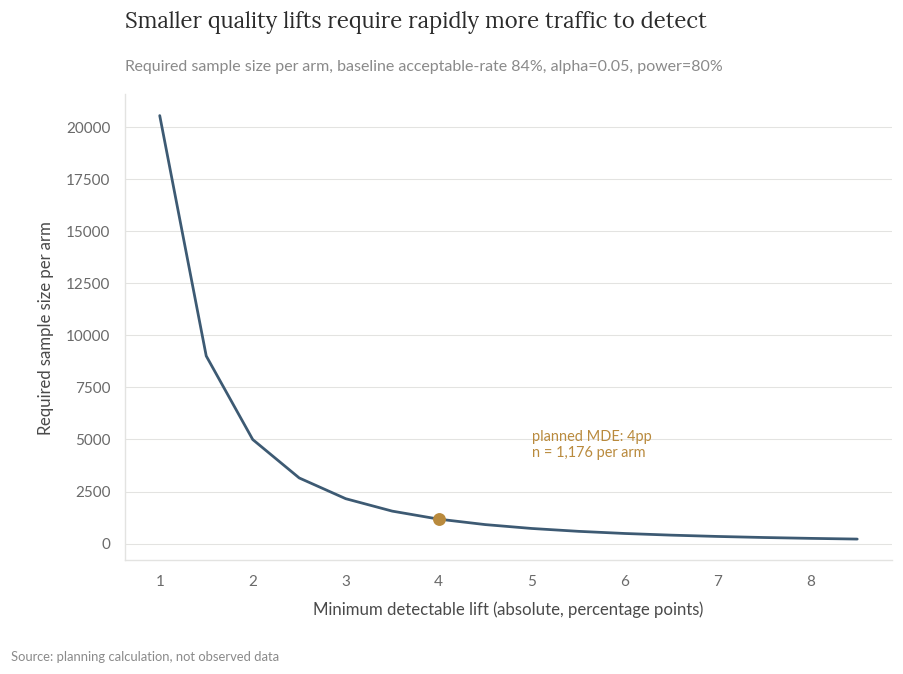

In [5]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

ALPHA = 0.05
POWER_TARGET = 0.80
BASELINE_RATE = 0.84
PLANNED_MDE = 0.04

def cohens_h(p1, p2):
    return 2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2))

analysis = NormalIndPower()
mde_range = np.arange(0.01, 0.09, 0.005)
sample_sizes = [analysis.solve_power(effect_size=abs(cohens_h(BASELINE_RATE, BASELINE_RATE + m)),
                                      alpha=ALPHA, power=POWER_TARGET, alternative="two-sided") for m in mde_range]
planned_n = analysis.solve_power(effect_size=abs(cohens_h(BASELINE_RATE, BASELINE_RATE + PLANNED_MDE)),
                                  alpha=ALPHA, power=POWER_TARGET, alternative="two-sided")

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(mde_range * 100, sample_sizes, color=SLATE, linewidth=1.8)
ax.scatter([PLANNED_MDE * 100], [planned_n], color=MUTED_AMBER, s=55, zorder=4)
ax.annotate(f"planned MDE: {PLANNED_MDE*100:.0f}pp\nn = {planned_n:,.0f} per arm", xy=(PLANNED_MDE * 100, planned_n),
            xytext=(PLANNED_MDE * 100 + 1.0, planned_n + 3000), fontsize=9.5, color=MUTED_AMBER)
style_ax(ax, title="Smaller quality lifts require rapidly more traffic to detect",
         subtitle=f"Required sample size per arm, baseline acceptable-rate {BASELINE_RATE:.0%}, alpha={ALPHA}, power={POWER_TARGET:.0%}",
         xlabel="Minimum detectable lift (absolute, percentage points)", ylabel="Required sample size per arm")
add_footnote(fig, "Source: planning calculation, not observed data")
plt.show()
print(f"Planned test: MDE={PLANNED_MDE*100:.0f}pp, required n/arm={planned_n:,.0f}")

**Figure 3.** Required sample size per arm by minimum detectable effect.

### 2b. Two-proportion test on the actual result

The test ran with roughly 3,000 tickets per arm, comfortably above the planned minimum (Figure 4).

In [6]:
ab = pd.read_csv("../data/ab_test_results.csv")
SOURCE_AB = f"Source: synthetic A/B test data · n = {len(ab):,} tickets"

counts = ab.groupby("arm")["judge_acceptable"].agg(["sum", "count"])
n_v1, n_v2 = counts.loc["v1_baseline", "count"], counts.loc["v2_revised", "count"]
x_v1, x_v2 = counts.loc["v1_baseline", "sum"], counts.loc["v2_revised", "sum"]
p_v1, p_v2 = x_v1 / n_v1, x_v2 / n_v2

z_stat, p_value = proportions_ztest([x_v2, x_v1], [n_v2, n_v1], alternative="two-sided")
ci_v1 = proportion_confint(x_v1, n_v1, alpha=ALPHA, method="wilson")
ci_v2 = proportion_confint(x_v2, n_v2, alpha=ALPHA, method="wilson")
lift_abs = p_v2 - p_v1
se_diff = np.sqrt(p_v1 * (1 - p_v1) / n_v1 + p_v2 * (1 - p_v2) / n_v2)
ci_diff = (lift_abs - 1.96 * se_diff, lift_abs + 1.96 * se_diff)

print(f"v1: {p_v1:.4f} ({x_v1}/{n_v1})   v2: {p_v2:.4f} ({x_v2}/{n_v2})")
print(f"Absolute lift: {lift_abs*100:.2f}pp, 95% CI [{ci_diff[0]*100:.2f}, {ci_diff[1]*100:.2f}]pp")
print(f"z={z_stat:.3f}, p={p_value:.5f}")

v1: 0.8400 (2488/2962)   v2: 0.9016 (2739/3038)
Absolute lift: 6.16pp, 95% CI [4.47, 7.85]pp
z=7.122, p=0.00000


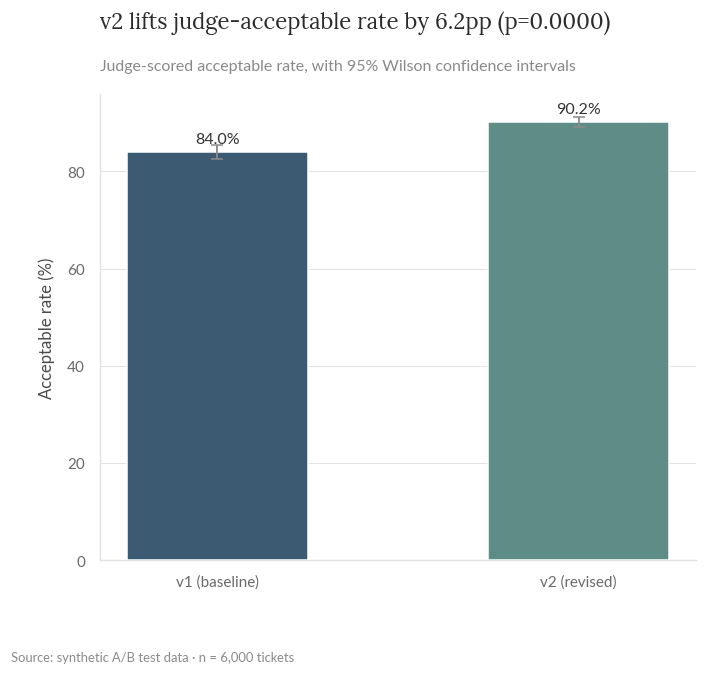

In [7]:
fig, ax = plt.subplots(figsize=(7, 5.5))
arms = ["v1 (baseline)", "v2 (revised)"]
rates = [p_v1 * 100, p_v2 * 100]
errs = [(p_v1 - ci_v1[0]) * 100, (p_v2 - ci_v2[0]) * 100]
ax.bar(arms, rates, yerr=[errs, errs], color=[SLATE, MUTED_TEAL], width=0.5, zorder=3,
       error_kw={"ecolor": GREY, "elinewidth": 1.2, "capsize": 4})
for i, v in enumerate(rates):
    ax.text(i, v + max(errs) + 0.5, f"{v:.1f}%", ha="center", fontsize=10.5, color="#333")
style_ax(ax, title=f"v2 lifts judge-acceptable rate by {lift_abs*100:.1f}pp (p={p_value:.4f})",
         subtitle="Judge-scored acceptable rate, with 95% Wilson confidence intervals", ylabel="Acceptable rate (%)")
add_footnote(fig, SOURCE_AB)
plt.show()

**Figure 4.** Judge-acceptable rate by arm, v1 vs. v2.

## 3. Production monitoring: a control chart on output quality

Once live, the feature needs monitoring the same way a model in production does, but standard input-drift monitoring (checking whether request volume or topic mix has shifted) can't catch a quality regression in what the model *outputs*. A p-chart (control chart for a proportion) on the daily judge-scored acceptable rate can.

In [8]:
monitoring = pd.read_csv("../data/quality_monitoring.csv").sort_values("day").reset_index(drop=True)
SOURCE_MON = f"Source: synthetic monitoring data · {len(monitoring)} days, {monitoring['n_tickets'].sum():,} tickets"

REFERENCE_END_DAY = 59
MIN_CONSECUTIVE_ALERTS = 3

reference = monitoring[monitoring["day"] <= REFERENCE_END_DAY]
center = reference["n_acceptable"].sum() / reference["n_tickets"].sum()
se = np.sqrt(center * (1 - center) / monitoring["n_tickets"].values)
ucl = np.clip(center + 3 * se, 0, 1)
lcl = np.clip(center - 3 * se, 0, 1)
out_of_control = monitoring["acceptable_rate"].values < lcl

detected_day = None
run_len = 0
for i, flagged in enumerate(out_of_control):
    run_len = run_len + 1 if flagged else 0
    if run_len >= MIN_CONSECUTIVE_ALERTS:
        detected_day = int(monitoring["day"].iloc[i - MIN_CONSECUTIVE_ALERTS + 1])
        break

print(f"Reference-period center line: {center:.1%}")
print(f"Days below control limit: {int(out_of_control.sum())} / {len(monitoring)}")
print(f"Regression detected starting day {detected_day} ({MIN_CONSECUTIVE_ALERTS}+ consecutive out-of-control days)")

Reference-period center line: 82.6%
Days below control limit: 30 / 120
Regression detected starting day 90 (3+ consecutive out-of-control days)


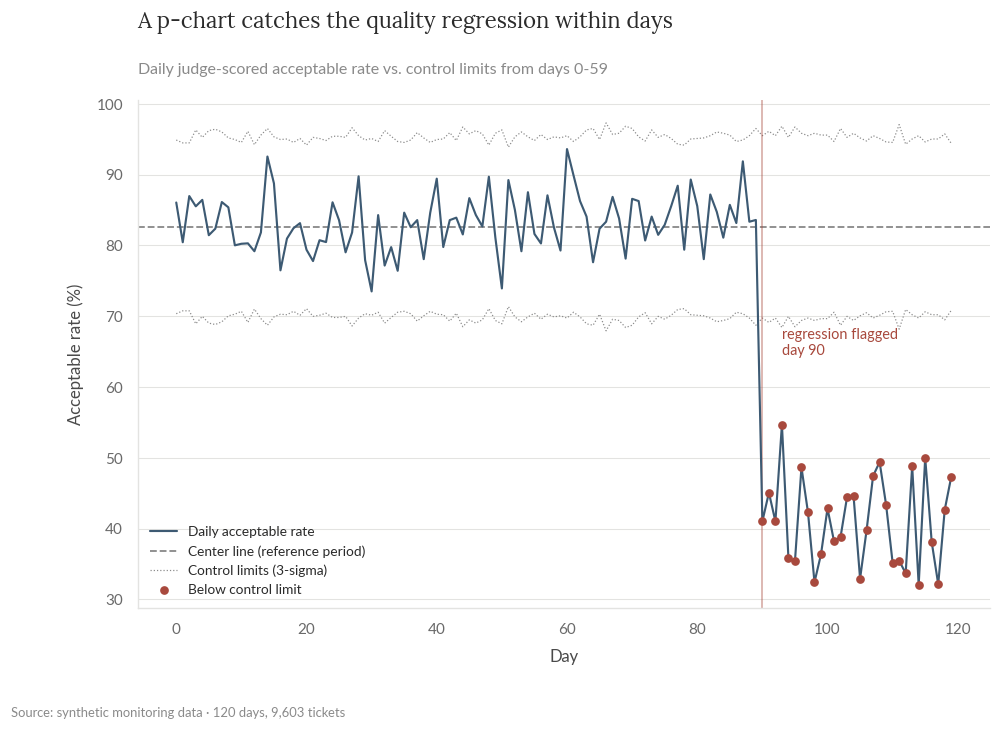

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(monitoring["day"], monitoring["acceptable_rate"] * 100, color=SLATE, linewidth=1.4, zorder=3, label="Daily acceptable rate")
ax.axhline(center * 100, color=GREY, linewidth=1.2, ls="--", label="Center line (reference period)")
ax.plot(monitoring["day"], ucl * 100, color=GREY, linewidth=0.8, ls=":")
ax.plot(monitoring["day"], lcl * 100, color=GREY, linewidth=0.8, ls=":", label="Control limits (3-sigma)")
alert_days = monitoring["day"].values[out_of_control]
alert_rates = monitoring["acceptable_rate"].values[out_of_control] * 100
ax.scatter(alert_days, alert_rates, color=MUTED_RED, s=22, zorder=4, label="Below control limit")
ax.axvline(detected_day, color=MUTED_RED, linewidth=1, ls="-", alpha=0.5)
ax.annotate(f"regression flagged\nday {detected_day}", xy=(detected_day, center * 100),
            xytext=(detected_day + 3, center * 100 - 18), fontsize=9.5, color=MUTED_RED)
style_ax(ax, title="A p-chart catches the quality regression within days",
         subtitle=f"Daily judge-scored acceptable rate vs. control limits from days 0-{REFERENCE_END_DAY}",
         xlabel="Day", ylabel="Acceptable rate (%)")
ax.legend(fontsize=9, loc="lower left")
add_footnote(fig, SOURCE_MON)
plt.show()

**Figure 5.** Daily p-chart: judge-scored acceptable rate against control limits.

The regression was injected on day 90 with no change in ticket volume or category mix; a feature-drift dashboard would show nothing. Scoring outputs directly and tracking them on a control chart flags it within the 3-day run-rule window, right at day 90 (Figure 5). Requiring a run of consecutive out-of-control days (rather than alerting on the first noisy day) is a deliberate trade-off: it costs a few days of detection lag in exchange for not paging anyone over ordinary day-to-day noise.

## 4. Guardrail threshold: auto-send vs. route-to-human

A separate, lightweight safety classifier scores every drafted reply with a risk probability before it's sent. Judging the classifier in isolation isn't the point; what matters is where to draw the line given what each error actually costs: a bad reply that gets auto-sent (remediation and trust cost) versus a fine reply that gets routed to a human anyway (reviewer time, paid on every routed reply regardless of outcome).

In [10]:
from sklearn.metrics import roc_auc_score

guardrail = pd.read_csv("../data/guardrail_scores.csv")
SOURCE_GUARD = f"Source: synthetic guardrail scoring data · n = {len(guardrail):,} replies"

COST_BAD_AUTO_SEND = 150.0
COST_HUMAN_REVIEW = 2.0

risk_score = guardrail["risk_score"].values
true_bad = guardrail["true_bad"].values
auc = roc_auc_score(true_bad, risk_score)

thresholds = np.linspace(0.01, 0.99, 99)
costs = []
for t in thresholds:
    routed = risk_score >= t
    auto_sent_bad = (~routed) & (true_bad == 1)
    cost = routed.sum() * COST_HUMAN_REVIEW + auto_sent_bad.sum() * COST_BAD_AUTO_SEND
    costs.append(cost)
costs = np.array(costs)
best_idx = costs.argmin()
best_t, best_cost = thresholds[best_idx], costs[best_idx]
default_idx = np.argmin(np.abs(thresholds - 0.50))
default_cost = costs[default_idx]
cost_reduction = 1 - best_cost / default_cost

print(f"Classifier AUC: {auc:.3f}")
print(f"Cost-optimal threshold: {best_t:.2f} (${best_cost:,.0f} vs ${default_cost:,.0f} at t=0.50, {cost_reduction:.1%} lower)")
print(f"Share routed to human review: {(risk_score >= best_t).mean():.1%} at optimal threshold vs. {(risk_score >= 0.50).mean():.1%} at t=0.50")

Classifier AUC: 0.848
Cost-optimal threshold: 0.16 ($13,730 vs $26,556 at t=0.50, 48.3% lower)
Share routed to human review: 72.7% at optimal threshold vs. 27.2% at t=0.50


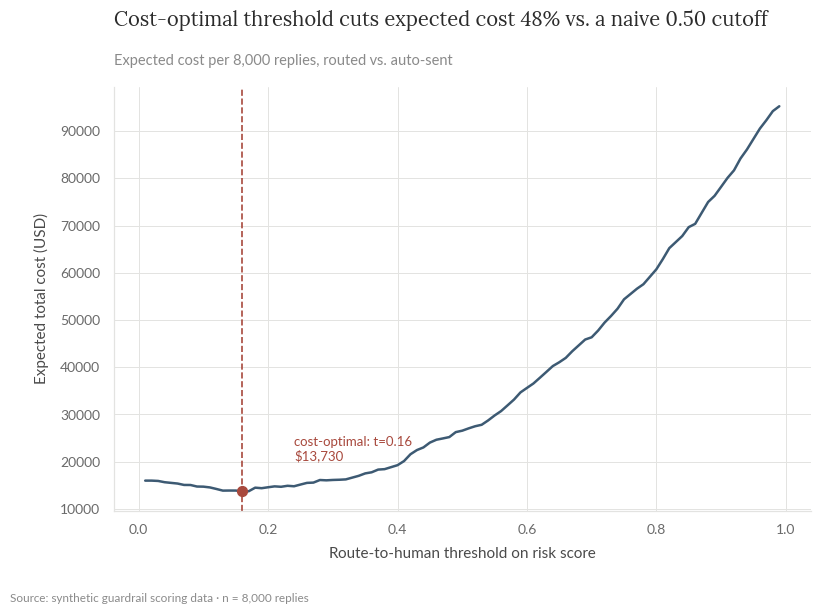

In [11]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(thresholds, costs, color=SLATE, linewidth=1.8)
ax.axvline(best_t, color=MUTED_RED, linewidth=1.2, ls="--")
ax.scatter([best_t], [best_cost], color=MUTED_RED, s=50, zorder=4)
ax.annotate(f"cost-optimal: t={best_t:.2f}\n${best_cost:,.0f}", xy=(best_t, best_cost),
            xytext=(best_t + 0.08, best_cost + (costs.max() - costs.min()) * 0.08), fontsize=9.5, color=MUTED_RED)
style_ax(ax, title=f"Cost-optimal threshold cuts expected cost {cost_reduction:.0%} vs. a naive 0.50 cutoff",
         subtitle=f"Expected cost per {len(guardrail):,} replies, routed vs. auto-sent",
         xlabel="Route-to-human threshold on risk score", ylabel="Expected total cost (USD)", grid_axis="both")
add_footnote(fig, SOURCE_GUARD)
plt.show()

**Figure 6.** Expected cost by auto-send threshold.

The cost-optimal threshold sits well below 0.50 and routes a majority of replies to human review (Figure 6), far more than intuition (or a default 0.5 cutoff) would suggest. That's a direct consequence of the cost asymmetry (a bad auto-send costs 75x a human review) combined with a classifier that, at AUC ~0.85 (it ranks a random bad reply above a random fine one 85% of the time), is good but not good enough to cleanly separate the two classes at a stricter threshold. The threshold itself is already cost-optimal; the constraint is the classifier's precision, and improving that would do more to shrink the review queue than adjusting the threshold further.

## 5. Limitations

- The judge-generosity model and the guardrail classifier's separability are both engineered to be plausible but are ultimately assumptions, not measurements from a real deployment; real judge bias and real classifier AUC would need to be established empirically per feature and per model version.
- The A/B test's outcome metric is the judge's score, not a downstream business outcome (e.g. ticket reopen rate, CSAT); section 1's validation work is what makes leaning on the judge for this defensible, but a real rollout decision should still triangulate with at least one downstream metric before shipping.
- The control chart's 3-day run rule is a specific, tunable trade-off between detection speed and false-alarm rate; a feature with a higher cost-per-bad-reply would justify a shorter run rule (faster detection, more false alarms) and vice versa.
- The guardrail cost assumptions ($150 per bad auto-send, $2 per human review) are illustrative placeholders; a real deployment would need actual cost data, and the optimal threshold is only as good as those inputs.